# Basic connectivity plots

Example notebook on how to generate basic connectivity plots from a ConnectivityMatrix object

In [1]:
import obi_one as obi
from pathlib import Path

In [2]:
matrix_path_prefix = Path("../../data/connectivity_matrices")

In [ ]:
basic_connectivity_plots_scan_config = obi.BasicConnectivityPlotsScanConfig(
                    initialize=obi.BasicConnectivityPlotsScanConfig.Initialize(
                        matrix_path=[
                                    # obi.NamedPath(name="fly", path="/Users/james/Documents/obi/code/obi-main/migration-scripts/entitycore/2026_register_flywire_lif_circuit/data/sonata_circuit_630__CONN_MATRIX__/drosophila__drosophila__brian2_synapse/single/connectivity_matrix.h5"),
                                     obi.NamedPath(name="N_10__top_rc_nodes_dim2_rc", path=str(matrix_path_prefix / "N_10__top_rc_nodes_dim2_rc" / "connectivity_matrix.h5"))
                                     ],
                        plot_formats=("png",),  # sub-tuple of ('png', 'pdf', 'svg'), if not specified all are plotted
                        rendering_cmap="custom",  # "custom" + .csv file OR Python cmap, e.g., "tab10"
                        rendering_color_file="colors_tab10.csv",
                        plot_types = ("nodes", "connectivity_global", "connectivity_pathway"),
                        # plot_types=("nodes",), # sub-tuple of ('nodes', 'connectivity_global', 'connectivity_pathway'), if not specified all are plotted
                        # dpi=int default 300
                    )
)

grid_scan = obi.GridScanGenerationTask(form=basic_connectivity_plots_scan_config, output_root="../../../../obi-output/basic_connectivity_plots/grid_scan", coordinate_directory_option="VALUE")
grid_scan.execute()

[2026-06-18 16:26:52,011] INFO: Plot Formats: ('png',)
[2026-06-18 16:26:52,012] INFO: Plot Types: ('nodes', 'connectivity_global', 'connectivity_pathway')
[2026-06-18 16:26:52,012] INFO: Info: Running idx 0, plots for ('nodes', 'connectivity_global', 'connectivity_pathway')
[2026-06-18 16:26:52,012] INFO: Info: Loading matrix 'fly'
[2026-06-18 16:26:53,905] INFO: Neuron, connection and synapse counts
[2026-06-18 16:26:53,906] INFO: [  127400 14687178 14687178]
[2026-06-18 16:33:34,366] INFO: Done with 0


[None]

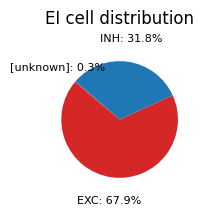

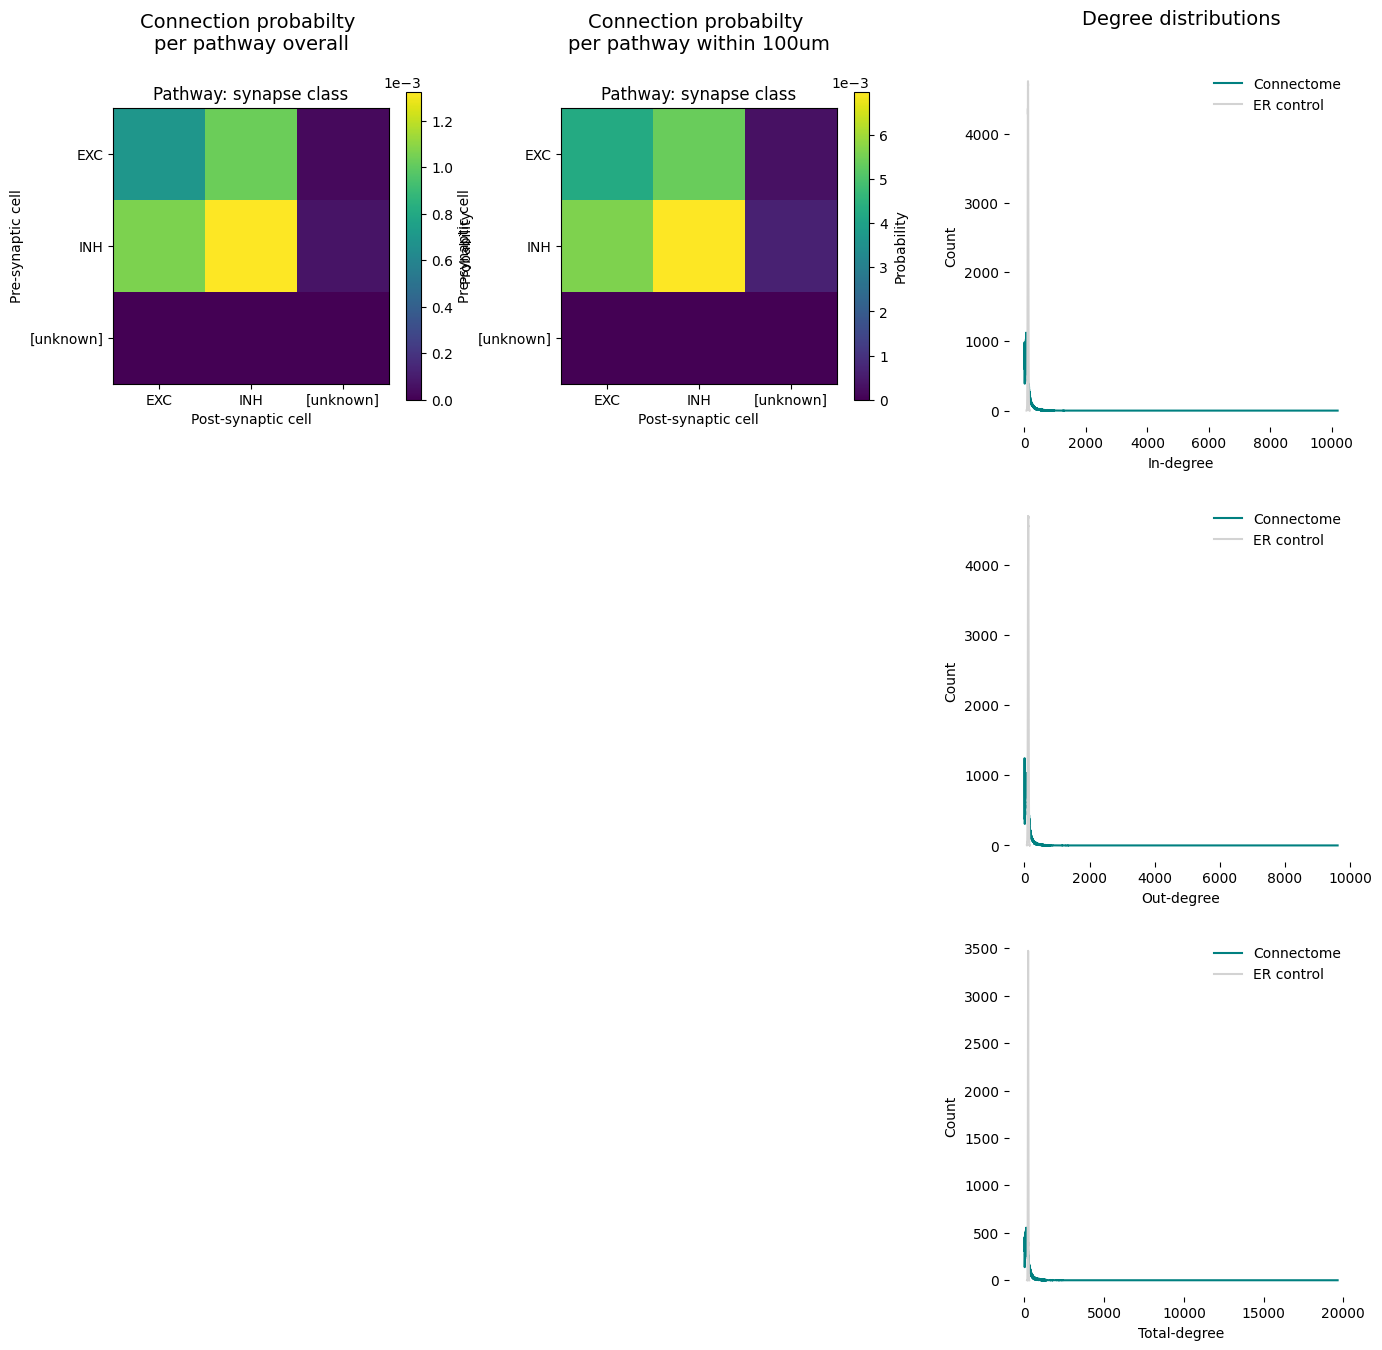

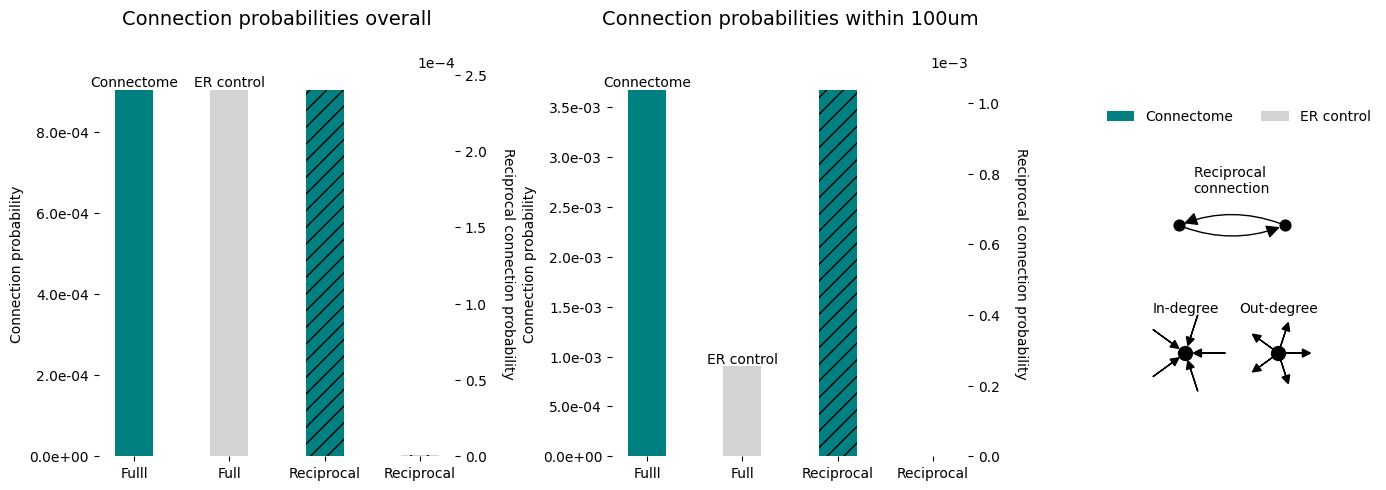

In [4]:
obi.run_tasks_for_generated_scan(grid_scan)

In [5]:
# Display the intermediary data
grid_scan.multiple_value_parameters(display=True)
grid_scan.coordinate_parameters(display=True)

[2026-06-18 16:33:34,597] INFO: 
MULTIPLE VALUE PARAMETERS
[2026-06-18 16:33:34,598] INFO: initialize.matrix_path: [fly]
[2026-06-18 16:33:34,598] INFO: 
COORDINATE PARAMETERS
[2026-06-18 16:33:34,599] INFO: initialize.matrix_path: fly


[SingleCoordinateScanParams(scan_params=[SingleValueScanParam(location_list=['initialize', 'matrix_path'], type='SingleValueScanParam', value=fly, index_in_scan_dimension=0)], nested_coordinate_subpath_str=PosixPath('.'), type='SingleCoordinateScanParams')]

In [6]:
# Deserialize
# grid_scan_ds = obi.deserialize_obi_object_from_json_file("../../../../obi-output/basic_connectivity_plots/grid_scan/obi_one_scan.json")
# grid_scan_ds